In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    hamming_loss,
    f1_score,
    precision_score,
    recall_score,
    multilabel_confusion_matrix,
)

import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

## Show the data

In [37]:
# Load the data
df = pd.read_csv("./datasets/bemo_prompts_dataset.csv")

In [38]:
# Show 5 random rows
df.sample(5)

,Unnamed: 0,prompt,general,smart_home,todo,mail,learning_resources,others
1660,1293,What's your background?,0,0,0,0,0,1
473,106,Plan a meeting with my team.,0,0,1,0,0,0
2453,2086,Do you understand yourself?,0,0,0,0,0,1
1420,1053,Deactivate the kitchen lights and email event ...,0,1,0,1,0,0
1203,836,I need to learn about data preprocessing; find...,0,0,1,0,1,0


In [39]:
# Drop the first column
df.drop(df.columns[0], axis=1, inplace=True)

In [40]:
df.sample(5)

,prompt,general,smart_home,todo,mail,learning_resources,others
1097,What data structures course would you recommend?,0,0,0,0,1,0
1880,Set the alarm.,0,1,0,0,0,0
1719,Could you please clarify quantum physics and s...,1,0,0,1,0,0
725,Could you tell me the game's winner from last ...,1,1,1,0,0,0
93,"Explain the concept of embeddings, add a note ...",1,0,1,1,1,0


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   prompt              3056 non-null   object
 1   general             3056 non-null   int64 
 2   smart_home          3056 non-null   int64 
 3   todo                3056 non-null   int64 
 4   mail                3056 non-null   int64 
 5   learning_resources  3056 non-null   int64 
 6   others              3056 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 167.2+ KB


In [42]:
df.describe()

,general,smart_home,todo,mail,learning_resources,others
count,3056.000000,3056.000000,3056.000000,3056.000000,3056.000000,3056.000000
mean,0.395615,0.318717,0.404450,0.342605,0.385144,0.148887
std,0.489062,0.466055,0.490866,0.474658,0.486709,0.356036
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
# Split the data into X and y
x = df["prompt"]
Y = df.drop(columns=["prompt"])

In [44]:
print(x.shape)
print(Y.shape)

(3056,)
(3056, 6)


## Evaluate the Model

In [45]:
# Load the model
model = pickle.load(
    open("./models/PromptToTask_MultiLabelClassifier_Optimized.pkl", "rb")
)
# Load the labels
labels = pickle.load(open("./models/labels.pkl", "rb"))

In [46]:
# Evaluate the model
Y_pred = model.predict(x)

print("Subset Accuracy:", accuracy_score(Y, Y_pred))
print("Hamming Loss:", hamming_loss(Y, Y_pred))
print("F1 Score (micro):", f1_score(Y, Y_pred, average="micro"))
print("F1 Score (macro):", f1_score(Y, Y_pred, average="macro"))
print("Precision (micro):", precision_score(Y, Y_pred, average="micro"))
print("Recall (micro):", recall_score(Y, Y_pred, average="micro"))

Subset Accuracy: 0.9685863874345549
Hamming Loss: 0.006544502617801047
F1 Score (micro): 0.9901558654634947
F1 Score (macro): 0.9898273589506458
Precision (micro): 0.9906434668417596
Recall (micro): 0.9896687438504428


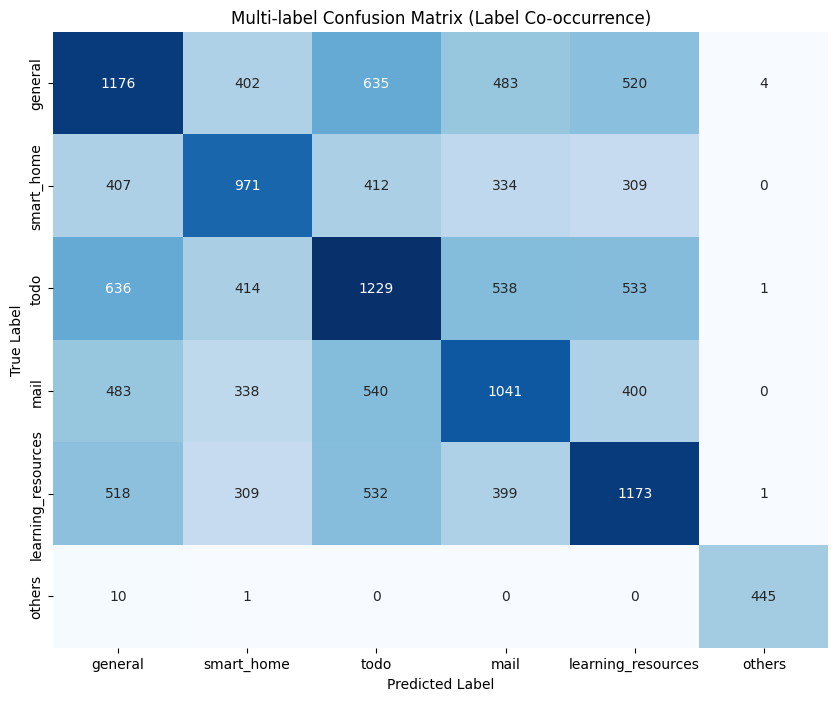

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Y and Y_pred should be numpy arrays or pandas DataFrames of shape (n_samples, n_labels)
if isinstance(Y, pd.DataFrame):
    Y_true = Y.values
    label_names = Y.columns
else:
    Y_true = Y
    label_names = [str(i) for i in range(Y.shape[1])]

if isinstance(Y_pred, pd.DataFrame):
    Y_pred = Y_pred.values

# Compute the co-occurrence confusion matrix
conf_matrix = np.dot(Y_true.T, Y_pred)

# Convert to int for heatmap annotation
conf_matrix = conf_matrix.astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    cbar=False,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Multi-label Confusion Matrix (Label Co-occurrence)")
plt.show()

## Explanation

### Core Idea

In the context of the B.E.M.O. assistant, accurate and efficient understanding of user intent is critical. User prompts can be complex and span multiple task domains (e.g., "Remind me to call John and also check my inbox"). Therefore, we developed a **multi-label text classification model** to assign each prompt to one or more of the following **six task categories**:

- `general`: Common questions or open-ended queries.
- `smart_home`: Commands related to controlling smart devices.
- `todo`: Tasks to be added to a to-do list.
- `mail`: Email-related actions or queries.
- `learning_resources`: Requests for educational material (books, videos, papers, etc.).
- `others`: Social greetings, small talk, or prompts that don’t fit any of the above.

This classifier acts as a **core decision-making unit**, enabling intelligent routing of prompts to appropriate downstream modules in the assistant’s architecture.

---

### Dataset Overview

- **File:** `bemo_prompts_dataset.csv`
- **Total samples:** 3,056 user prompts
- **Annotation:** Each prompt is manually annotated with binary labels (1 or 0) for the six tasks
- **Label distribution:**
  - Prompts may belong to **more than one label**, requiring multi-label classification (not multi-class)
  - The dataset contains co-occurring labels and overlapping semantics, e.g., a prompt may belong to both `todo` and `mail`

---

### Model Architecture

- **Model file:** `PromptToTask_MultiLabelClassifier_Optimized.pkl`
- **Type:** Multi-label text classification pipeline
- **Pipeline components:**
  - `TfidfVectorizer`: Converts raw prompt text into TF-IDF features
  - `ClassifierChain(LogisticRegression())`: A chain of binary classifiers, each predicting one label conditioned on the others
- **Training details:**
  - Trained on the full dataset after hyperparameter tuning using `GridSearchCV`
  - Model supports online predictions with high efficiency and interpretability

---

### Evaluation Metrics and Results

The model was evaluated on the **entire dataset** to measure its effectiveness in real-world prompt handling. Since the task is **multi-label**, standard single-label metrics are not sufficient. The following multi-label metrics were computed:

#### 1. **Subset Accuracy**  
- **Score:** `0.9686`  
- **Definition:**  
  The proportion of samples where the **entire predicted label set exactly matches the true label set**.  
  
  $$
  \text{Subset Accuracy} = \frac{1}{n} \sum_{i=1}^{n} \mathbb{1}[\hat{Y}_i = Y_i]
  $$

- **Interpretation:**  
  This is a **very strict metric** — partial correctness is not rewarded. A score of **0.9686** indicates that ~97% of the time, the model predicts **all correct labels** for a prompt with **no mistakes**.

---

#### 2. **Hamming Loss**  
- **Score:** `0.0065`  
- **Definition:**  
  The fraction of labels that are incorrectly predicted (either a label is wrongly included or omitted).  
  
  $$  
  \text{Hamming Loss} = \frac{1}{n \times L} \sum_{i=1}^{n} \sum_{j=1}^{L} \mathbb{1}[\hat{Y}_{ij} \ne Y_{ij}]
  $$

  where \(L\) is the number of labels.
- **Interpretation:**  
  A score of **0.0065** implies that **only 0.65%** of the total labels were incorrectly predicted — an **extremely low error rate** for a multi-label task.

---

#### 3. **F1 Score (Micro-Averaged)**  
- **Score:** `0.9902`  
- **Definition:**  
  The harmonic mean of micro-averaged precision and recall. Micro-averaging aggregates the contributions of **all classes** to compute the average metric.  
  
  $$
  F1_{\text{micro}} = \frac{2 \cdot \text{Precision}_{\text{micro}} \cdot \text{Recall}_{\text{micro}}}{\text{Precision}_{\text{micro}} + \text{Recall}_{\text{micro}}}
  $$

- **Interpretation:**  
  High micro-F1 reflects excellent **overall performance**, especially in imbalanced datasets. The score of **0.9902** shows that the model performs very well across all instances.

---

#### 4. **F1 Score (Macro-Averaged)**  
- **Score:** `0.9898`  
- **Definition:**  
  The mean of F1 scores computed separately for each label. Each class is treated **equally**, regardless of frequency.  
  
  $$
  F1_{\text{macro}} = \frac{1}{L} \sum_{j=1}^{L} F1_j
  $$

- **Interpretation:**  
  This score emphasizes **per-label performance**. A macro-F1 of **0.9898** indicates that each label, even less frequent ones, is being predicted accurately.

---

#### 5. **Precision (Micro)**  
- **Score:** `0.9906`  
- **Definition:**  
  The ratio of true positives to all predicted positives, aggregated across all labels.  
  $$
  \text{Precision}_{\text{micro}} = \frac{\sum TP}{\sum TP + \sum FP}
  $$
- **Interpretation:**  
  Indicates that when the model predicts a label, it is correct **99.06% of the time**.

---

#### 6. **Recall (Micro)**  
- **Score:** `0.9897`  
- **Definition:**  
  The ratio of true positives to all actual positives across all labels.  
  $$
  \text{Recall}_{\text{micro}} = \frac{\sum TP}{\sum TP + \sum FN}
  $$
- **Interpretation:**  
  Shows that the model successfully captures **~99% of all true labels**.

---

### Confusion Matrix Analysis

- A **multi-label co-occurrence confusion matrix** was computed and visualized as a heatmap.
- **Diagonal elements** represent the number of times each label was **correctly predicted**.
- **Off-diagonal elements** indicate **confusion** or **co-occurrence**, i.e., when a label was predicted but not actually present (or vice versa).
- **Findings:**
  - Strong diagonal dominance → High label-wise accuracy
  - Mild confusion observed between:
    - `general` and `todo` (possibly due to vague user intent)
    - `mail` and `learning_resources` (requests like “send me a paper” may overlap)
  - `others` label is rarely confused, indicating good semantic isolation


<center>

![](./multi_label_confusion_matrix.png)

</center>

---

### Conclusion

- The B.E.M.O. multi-label prompt classifier demonstrates **excellent performance across all standard multi-label metrics**.
- The model is capable of accurately assigning multiple relevant task labels to diverse natural language inputs.
- This evaluation confirms that the model is **suitable for deployment** in real-time systems, offering:
  - **High precision and recall**
  - **Minimal error rates**
  - **Robust handling of overlapping task semantics**
